# Predicting the Success of a Kickstarter Project

## Import libraries

In [1]:
import os, json
import pandas as pd
import numpy as np
import warnings
import datetime
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import EDA_plots as EDA
import evaluate_models as em
import pipeline as pipe

warnings.filterwarnings("ignore")

RSEED = 1312

---

## Prepare data

### Import dataframe

Drop coluns which are "outcome" features like _number of backers_ or _USD pledged_, because these reflect the success of a project and can not be used to try to predict that outcome.

In [2]:
# --- import dataframe ---
df = pd.read_csv(os.path.join("data", "df_preprocessed.csv"))

In [3]:
# get rid of "outcome" features & create new df
df = df.drop(
    columns=[
        "backers_count",
        "created_at",
        "deadline_at",
        "launched_at",
        "staff_pick",
        "usd_pledged",
        "pledge_per_backer",
    ],
    axis=1,
)

# target variable
df = df.replace({"state": {"failed": 0, "successful": 1}})
df = df.rename(columns={"state": "outcome"})

# prepare some variables
target = "outcome"
target_labels = ["failed", "successful"]
cat_feat = df.select_dtypes(exclude=["number"]).columns.to_list()
num_feat = df.select_dtypes(include=["number"]).columns.to_list()
num_feat.remove(target)

# print infos
print("Numerical features are: ", num_feat)
print("Categorical features are: ", cat_feat)
df.info()

Numerical features are:  ['usd_goal', 'name_length', 'blurb_length', 'preparation_days', 'campaign_days', 'year']
Categorical features are:  ['category', 'country', 'deadline_day', 'deadline_month', 'launch_day', 'launch_month']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214197 entries, 0 to 214196
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   category          214197 non-null  object 
 1   country           214197 non-null  object 
 2   outcome           214197 non-null  int64  
 3   usd_goal          214197 non-null  float64
 4   name_length       214197 non-null  int64  
 5   blurb_length      214197 non-null  float64
 6   preparation_days  214197 non-null  int64  
 7   campaign_days     214197 non-null  int64  
 8   deadline_day      214197 non-null  object 
 9   deadline_month    214197 non-null  object 
 10  launch_day        214197 non-null  object 
 11  launch_month      214197 non-nu

### Log transformation

Some of the numerical features are highly skewed and will be log transformed.
Features to be log-transformed are `usd_goal`, `name_length`, and `preparation_days`.

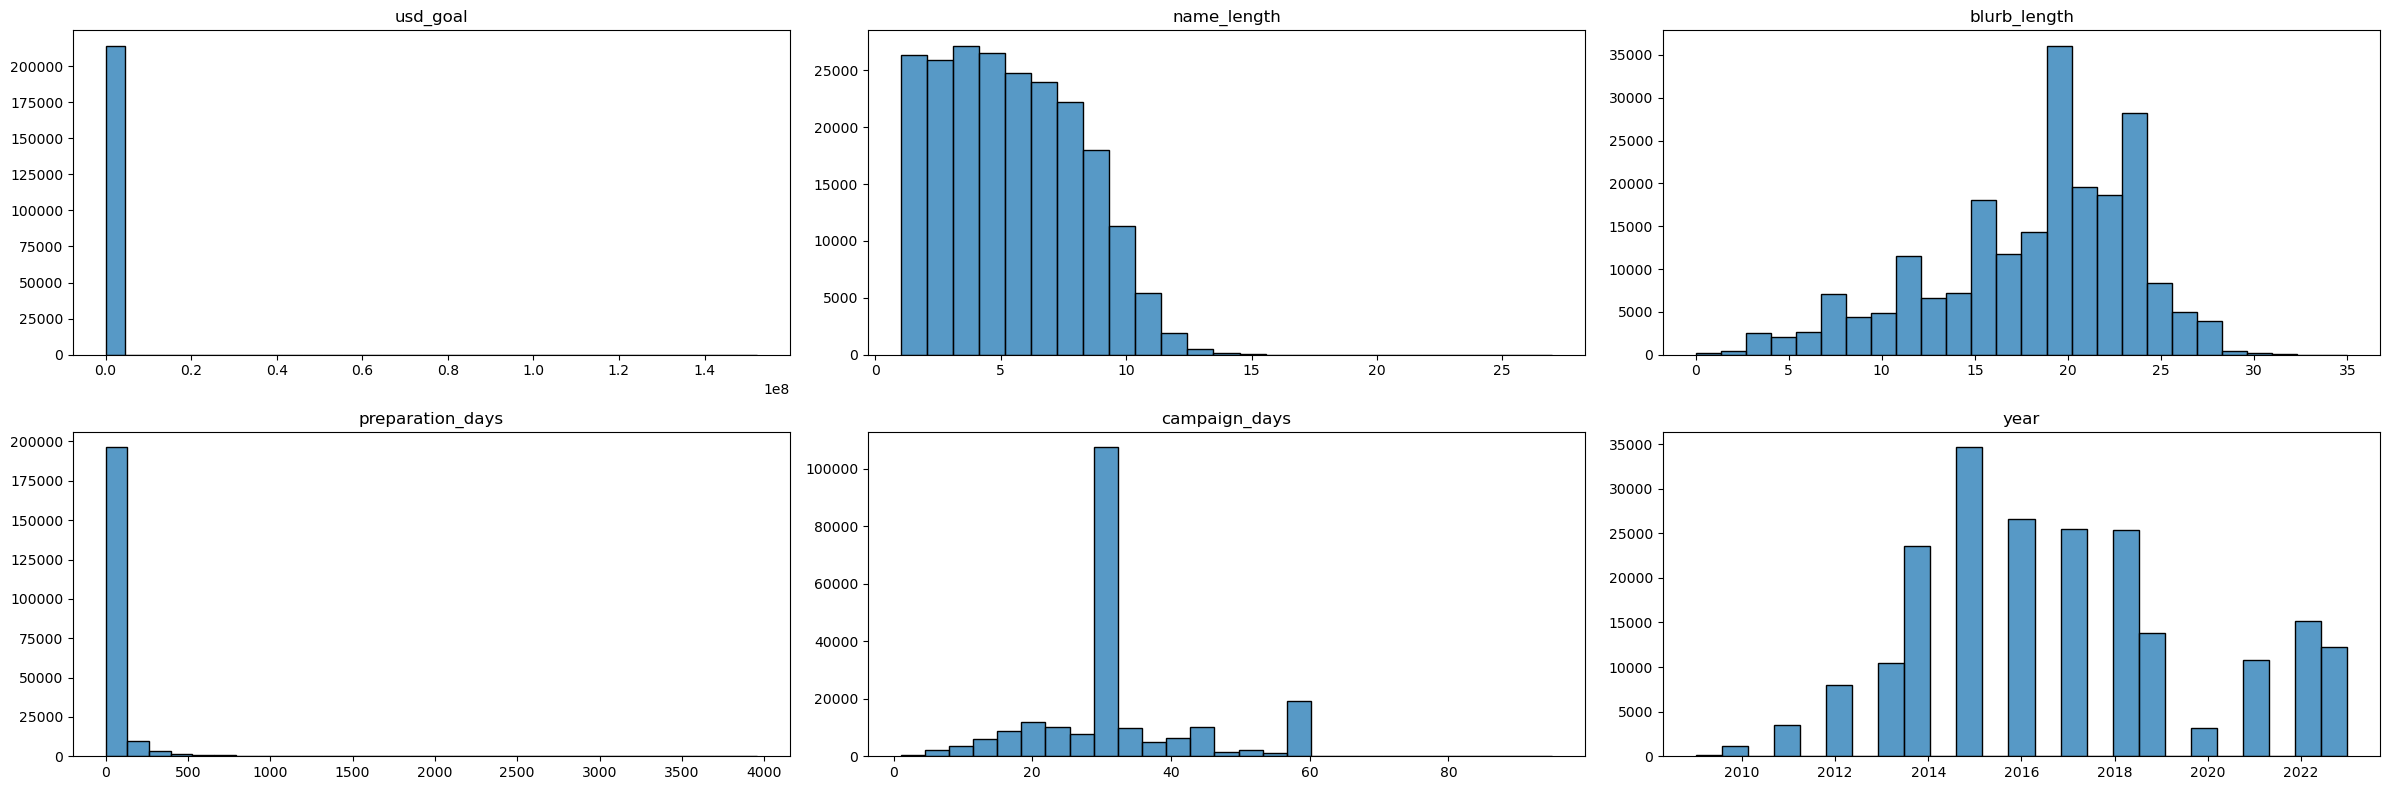

,count,mean,std,min,25%,50%,75%,max
outcome,214197.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
usd_goal,214197.0,36176.0,1002468.0,0.0,1295.0,4500.0,12000.0,152350076.0
name_length,214197.0,6.0,3.0,1.0,4.0,6.0,8.0,27.0
blurb_length,214197.0,18.0,5.0,0.0,15.0,19.0,22.0,35.0
preparation_days,214197.0,50.0,138.0,0.0,3.0,13.0,40.0,3959.0
campaign_days,214197.0,32.0,12.0,1.0,29.0,30.0,33.0,95.0
year,214197.0,2017.0,3.0,2009.0,2015.0,2016.0,2019.0,2023.0


In [4]:
# --- show distributions ---
EDA.histplots(df[num_feat], bins="doane", cols=3)
df.describe().round(0).T

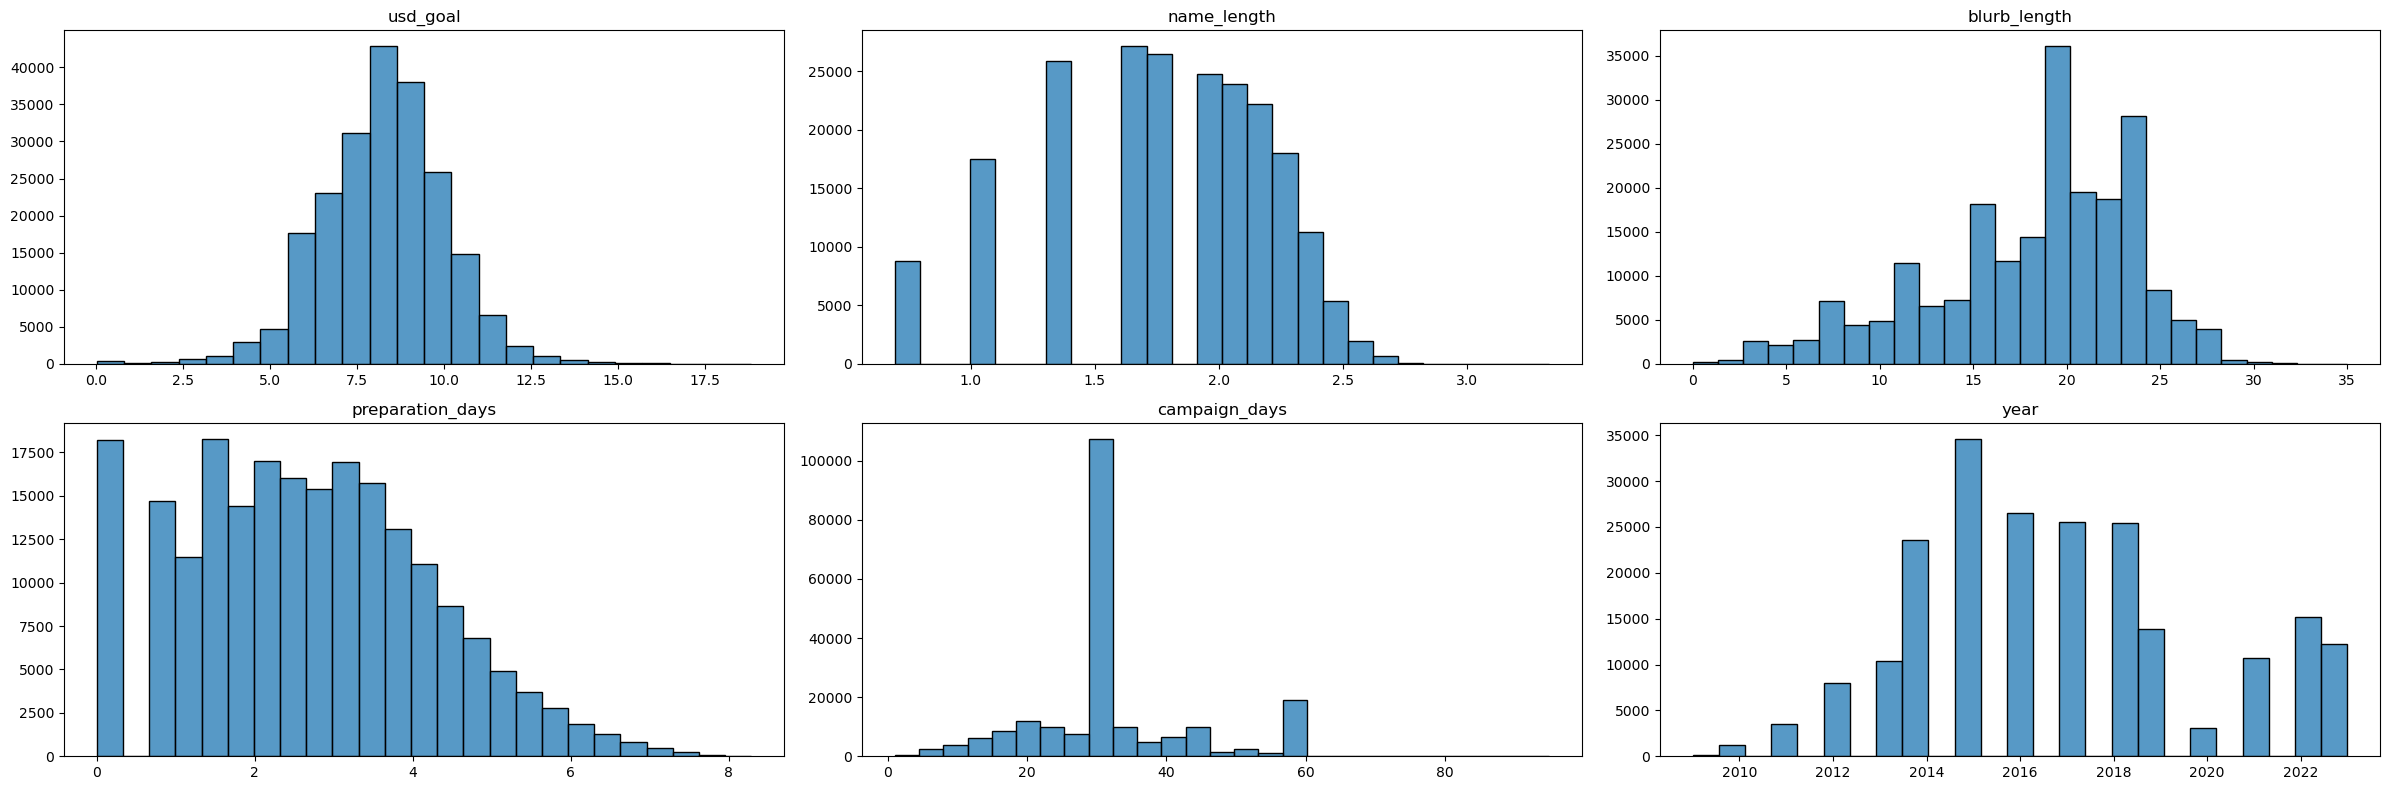

In [5]:
# --- apply log transformation ---
for f in ["usd_goal", "name_length", "preparation_days"]:
    df[f] = df[f].apply(lambda x: np.log(x + 1))

EDA.histplots(df[num_feat], bins="doane", cols=3)

### Train-Test-Split

In [6]:
# define predictors and target variable
X = df
y = X.pop(target)

print(f"We have {X.shape[0]} observations in our dataset and {X.shape[1]} features")
print(f"Our target vector has also {y.shape[0]} values")

# Split into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RSEED
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

We have 214197 observations in our dataset and 12 features
Our target vector has also 214197 values
X_train shape: (171357, 12)
X_test shape: (42840, 12)
y_train shape: (171357,)
y_test shape: (42840,)


---

## Baseline model

Looking at some figures created during the EDA, it becomes obvious that some features differ between successful and failed projects. Based on my observations, I'll predict a project as successful, if the follwoing criteria are met:

- category does not belong to `Crafts`, `Photography`, `Technology`, `Journalism` or `Food`, since they have a lower as 50% successrate
- AND 
  - `prepartion time` longer as `median(preparation time)`
    - _OR_
  - `usd goal` lower as `median(usd goal)`
    - _because_ either they prepare very well OR the target is low enough to be achieved easily

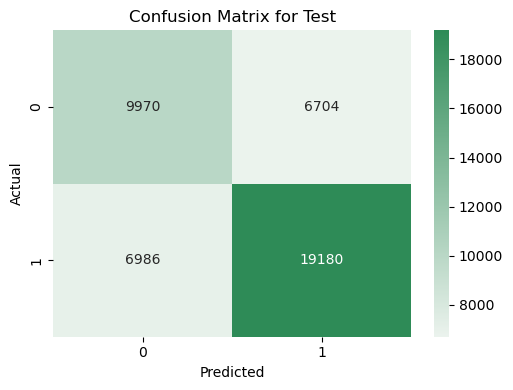

--------------- classification report for Test ---------------
              precision    recall  f1-score   support

           0      0.588     0.598     0.593     16674
           1      0.741     0.733     0.737     26166

    accuracy                          0.680     42840
   macro avg      0.664     0.665     0.665     42840
weighted avg      0.681     0.680     0.681     42840

F(0.5) - score: 0.739


In [7]:
# find rows with mathing features
baseline_idx = X_test[
    (
        ~X_test["category"].isin(
            ["Crafts", "Photography", "Technology", "Journalism", "Food"]
        )
    )
    & (
        (X_test["preparation_days"] > X_train["preparation_days"].median())
        | (X_test["usd_goal"] < X_train["usd_goal"].median())
    )
].index

# create prediction pd.series
baseline_pred = pd.Series(np.zeros((X_test.shape[0], )), index=X_test.index)
baseline_pred[baseline_idx] = 1.0

# report results
em.report(y_test, baseline_pred)

---

## Pipelines

Here, i'll prepare sckit-learn pipelines which will be used in the following classifications.

### Set default parameters

As the metric to be optimized i decided for a f_beta score with beta=0.5, which puts more weight on precision. While avoiding false negatives (missing chances of successful projects) is also a desirable outcome, it is more important to achieve a high precision and avoif false positives (loosing time/money in unsuccessful projects).

In [8]:
# defaults
cv = 5
RS_iter = 100
n_jobs = -1
verbose = 0

# metric
fhalf_scorer = make_scorer(fbeta_score, beta=0.5)
ftwo_scorer = make_scorer(fbeta_score, beta=2)

# overwrite models
overwrite = False  # choose to overwrite files
add_suffix = False  # OR add suffix, if filename already exists

### pipe: preproccessor

In [9]:
# preprocessor for numerical & categorical features
num_pipeline = Pipeline([("std_scaler", StandardScaler())])
cat_pipeline = Pipeline([("1hot", OneHotEncoder(handle_unknown="ignore"))])

# Complete pipeline for numerical and categorical features
# 'ColumnTransformer' applies transformers (num_pipeline/ cat_pipeline)
# to specific columns of an array or DataFrame (num_features/cat_features)
preprocessor = ColumnTransformer(
    [("num", num_pipeline, num_feat), ("cat", cat_pipeline, cat_feat)]
)

### pipe: Logistic Regression

In [10]:
# logisitic regression pipeline
LR_pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "logreg",
            LogisticRegression(
                max_iter=1000, random_state=RSEED, n_jobs=n_jobs, verbose=verbose
            ),
        ),
    ]
)

### pipe: Random Forest

In [11]:
# random forest pipeline
RF_pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rForest",
            RandomForestClassifier(random_state=RSEED, n_jobs=n_jobs, verbose=verbose),
        ),
    ]
)

---

## Logistic Regression

### cross_validation of train set

Perform a cross-validation on the training set to get a sense of how well logistic regression is able to find patterns wihti the data and predict the outcome.

In [ ]:
# run cross-validation
LR_y_train_pred_cv = cross_val_predict(
    LR_pipe, X_train, y_train, cv=cv, n_jobs=n_jobs, verbose=verbose
)

# report results
em.report(y_train=y_train, y_train_pred=LR_y_train_pred_cv)

#### Optimizing via Grid Search

In [ ]:
# define parameter grid
param_logreg = {
    "logreg__penalty": ("l1", "l2"),
    "logreg__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "logreg__solver": ["liblinear", "newton-cg", "lbfgs", "sag", "saga"],
    "logreg__class_weight": [None, "balanced"],
}

from sklearn.metrics import fbeta_score, make_scorer
ftwo_scorer = make_scorer(fbeta_score, beta=2)

# intantiate GridSearchCV
LR_gs = GridSearchCV(
    LR_pipe,
    param_grid=param_logreg,
    cv=cv,
    scoring=ftwo_scorer,
    verbose=verbose,
    n_jobs=n_jobs,
)

In [ ]:
# fit GridSearchCV
model_name = "LR_gs.pickle"
if (
    not os.path.exists(os.path.join("models", f"{model_name}"))
    or overwrite
    or add_suffix
):
    LR_gs.fit(X_train, y_train)
    em.save_model(LR_gs, model_name)
else:
    LR_gs = pickle.load(open(os.path.join("models", f"{model_name}"), "rb"))

# display pipeline
LR_gs

In [ ]:
# evaluate GridSearch results
y_test_predicted = em.eval_grid_search(LR_gs, X_test)
em.report(y_test=y_test, y_test_pred=y_test_predicted)

---

## Random Forest

### Cross-Validation

In [ ]:
# # run cross-validation
# RF_y_train_pred_cv = cross_val_predict(
#     RF_pipe, X_train, y_train, cv=cv, n_jobs=n_jobs, verbose=verbose
# )

# # report results
# em.report(y_train=y_train, y_train_pred=RF_y_train_pred_cv)

### Optimizing via RandomSearch

In [16]:
# Hyperparameter grid
param_grid = {
    "n_estimators": np.linspace(10, 500).astype(int),
    "max_depth": [None] + list(np.linspace(3, 20).astype(int)),
    "max_features": ["log2", "sqrt", None] + list(np.arange(0.5, 1, 0.1)),
    "max_leaf_nodes": [None] + list(np.linspace(10, 500).astype(int)),
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "bootstrap": [True, False],
}

# intantiate RandomizedSearchCV
RF_rs = RandomizedSearchCV(
    RF_pipe,
    param_grid,
    n_jobs=-1,
    scoring=fhalf_scorer,
    cv=cv,
    n_iter=RS_iter,
    verbose=verbose,
    random_state=RSEED,
)

In [17]:
# fit RandomSearchCV
model_name = "RD_rs.pickle"
if (
    not os.path.exists(os.path.join("models", f"{model_name}"))
    or overwrite
    or add_suffix
):
    RF_rs.fit(X_train, y_train)
    em.save_model(LR_gs, model_name)
else:
    RF_rs = pickle.load(open(os.path.join("models", f"{model_name}"), "rb"))

# display pipeline
RF_rs

ValueError: Invalid parameter 'n_estimators' for estimator Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('std_scaler',
                                                                   StandardScaler())]),
                                                  ['usd_goal', 'name_length',
                                                   'blurb_length',
                                                   'preparation_days',
                                                   'campaign_days', 'year']),
                                                 ('cat',
                                                  Pipeline(steps=[('1hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['category', 'country',
                                                   'deadline_day',
     